In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import sys
import os
from tqdm import tqdm

project_root = os.path.dirname(os.path.abspath(''))
if project_root not in sys.path:
    sys.path.append(project_root)

from FEATURES.features import *
from MODELS.pipeline import *
from MODELS.xgboostModel import *
from MODELS.ngboostModel import *

c:\Users\alexg\OneDrive\Documents\NBA-Prop-Predictor\nba_model\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:

pd.set_option('display.max_columns', None)

# s19 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_19.csv')
s20 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_20.csv')
s21 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_21.csv')
s22 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_22.csv')
s23 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_23.csv')
s24 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_24.csv')
s25 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_25.csv')
s26 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_26.csv')

def cap_outliers_per_player(df, target_col='PTS', p_low=0.01, p_high=0.99):
    """Cap target values at specified percentiles per player."""
    df_capped = df.copy()
    for player_id in df_capped['PLAYER_ID'].unique():
        mask = df_capped['PLAYER_ID'] == player_id
        p_low_val = df_capped.loc[mask, target_col].quantile(p_low)
        p_high_val = df_capped.loc[mask, target_col].quantile(p_high)
        df_capped.loc[mask, target_col] = df_capped.loc[mask, target_col].clip(p_low_val, p_high_val)
        print(f"Player {player_id}: PTS range capped [{p_low_val:.1f}, {p_high_val:.1f}]")
    return df_capped

# Training data
train_df = pd.concat([s20,s21,s22,s23,s24,s25,s26])
train_df = train_df[train_df['MIN'] > 10]  
train_df = cap_outliers_per_player(train_df, 'PTS', p_low=0.01, p_high=0.99)

# Validation data
# val_df = s25
# val_df = val_df[val_df['MIN'] > 10] 
# val_df = cap_outliers_per_player(val_df, 'PTS', p_low=0.01, p_high=0.99)

print(f"Train set: {len(train_df)} samples")
# print(f"Val set: {len(val_df)} samples")
# print(f"Test set: {len(test_df)} samples")
train_df.sample(5)

C:\Users\alexg\AppData\Local\Temp\ipykernel_29260\1642795215.py:22: DtypeWarning: Columns (33) have mixed types. Specify dtype option on import or set low_memory=False.
  s26 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_26.csv')


Player 1713: PTS range capped [0.0, 16.0]
Player 2199: PTS range capped [0.0, 9.7]
Player 2544: PTS range capped [10.6, 46.4]
Player 2546: PTS range capped [1.9, 29.0]
Player 2594: PTS range capped [0.0, 20.9]
Player 2617: PTS range capped [0.0, 23.0]
Player 2730: PTS range capped [0.0, 21.0]
Player 2738: PTS range capped [0.0, 12.8]
Player 2747: PTS range capped [0.1, 10.8]
Player 2772: PTS range capped [0.0, 21.0]
Player 101107: PTS range capped [0.0, 21.5]
Player 101108: PTS range capped [0.0, 30.0]
Player 101133: PTS range capped [2.0, 23.6]
Player 101139: PTS range capped [0.0, 20.5]
Player 101141: PTS range capped [0.0, 18.8]
Player 101150: PTS range capped [1.8, 32.4]
Player 200746: PTS range capped [1.2, 37.7]
Player 200752: PTS range capped [0.0, 22.0]
Player 200755: PTS range capped [0.0, 31.0]
Player 200757: PTS range capped [0.0, 9.0]
Player 200765: PTS range capped [0.0, 20.3]
Player 200768: PTS range capped [0.0, 32.0]
Player 200782: PTS range capped [0.0, 18.2]
Player 20

,Unnamed: 0,PLAYER_NAME,PLAYER_ID,MATCHUP,TEAM_ABBREVIATION,TEAM_ID,OPP_ABBREVIATION,HOME_GAME,GAME_ID,GAME_DATE,WL,PTS,AST,REB,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,STL,BLK,TOV,PLUS_MINUS,FANTASY_PTS,POINT_PER_SHOT,EFG,START_POSITION,COMMENT,OFF_RATING,E_OFF_RATING,DEF_RATING,E_DEF_RATING,NET_RATING,OREB_PCT,DREB_PCT,REB_PCT,AST_PCT,EFG_PCT,AST_TOV,USG_PCT,TS_PCT,E_PACE,PACE,PIE,POSS,PACE_PER40,E_USG_PCT,MIN,SPD,DIST,ORBC,DRBC,RBC,TCHS,SAST,FTAST,PASS,CFGM,CFGA,CFG_PCT,UFGM,UFGA,UFG_PCT,DFGM,DFGA,DFG_PCT,PTS_OFF_TOV,PTS_2ND_CHANCE,PTS_FB,PTS_PAINT,OPP_PTS_OFF_TOV,OPP_PTS_2ND_CHANCE,OPP_PTS_FB,OPP_PTS_PAINT,BLKA,PF,PFD,IS_PLAYOFF,TEAM_NAME,TEAM_MIN,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_STL,TEAM_BLK,TEAM_TOV,TEAM_PF,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_PACE,GAME_PACE,OPP_PACE,OPP_TEAM_ID,TEAM_OFF_RATING,TEAM_DEF_RATING,OPP_DEF_RATING,OPP_OFF_RATING,OPP_PTS,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_REB,OPP_AST,OPP_STL,OPP_BLK,OPP_TOV,whos_favored,spread,total,team_is_favored,team_spread,percentageFieldGoalsAttempted2pt,percentageFieldGoalsAttempted3pt,percentagePoints2pt,percentagePointsMidrange2pt,percentagePoints3pt,percentagePointsFastBreak,percentagePointsFreeThrow,percentagePointsOffTurnovers,percentagePointsPaint,percentageAssisted2pt,percentageUnassisted2pt,percentageAssisted3pt,percentageUnassisted3pt,percentageAssistedFGM,percentageUnassistedFGM,matchupFieldGoalsMade,matchupFieldGoalsAttempted,matchupThreePointersMade,matchupThreePointersAttempted,playerPoints,matchupMinutes,DEF_FG_PCT_ALLOWED,DEF_3PT_PCT_ALLOWED,PTS_ALLOWED_PER_MIN,DEF_TOV_FORCED_PER_MIN,DEF_BLOCKS_PER_MIN,DEF_SHOOTING_FOULS_PER_MIN,DEF_AST_ALLOWED_PER_MIN,GP,AGE,FREQ_FG3,FG3M_main,FG3A_main,FG3_PCT_main,NS_FG3_PCT,PLUS_MINUS_FG3,FREQ_FG2,FG2M,FG2A,FG2_PCT,NS_FG2_PCT,PLUS_MINUS_FG2,FREQ_LT_06,FGM_LT_06,FGA_LT_06,LT_06_PCT,NS_LT_06_PCT,PLUS_MINUS_LT_06,FREQ_LT_10,FGM_LT_10,FGA_LT_10,LT_10_PCT,NS_LT_10_PCT,PLUS_MINUS_LT_10,FREQ_GT_15,FGM_GT_15,FGA_GT_15,GT_15_PCT,NS_GT_15_PCT,PLUS_MINUS_GT_15,STARTING,HEIGHT,WEIGHT,GUARD,FORWARD,CENTER,TEAM_DAYS_REST,PLAYER_DAYS_REST,TEAM_B2B,IS_BACK_TO_BACK,PLAYER_MISSED_LAST,PTS_ROLLING_AVG_5,AST_ROLLING_AVG_5,FGM_ROLLING_AVG_5,FGA_ROLLING_AVG_5,FG_PCT_ROLLING_AVG_5,FG3M_ROLLING_AVG_5,FG3A_ROLLING_AVG_5,FG3_PCT_ROLLING_AVG_5,FTA_ROLLING_AVG_5,FTM_ROLLING_AVG_5,FT_PCT_ROLLING_AVG_5,TOV_ROLLING_AVG_5,TS_PCT_ROLLING_AVG_5,USG_PCT_ROLLING_AVG_5,MIN_ROLLING_AVG_5,PACE_ROLLING_AVG_5,PIE_ROLLING_AVG_5,E_OFF_RATING_ROLLING_AVG_5,NET_RATING_ROLLING_AVG_5,TCHS_ROLLING_AVG_5,POSS_ROLLING_AVG_5,EFG_PCT_ROLLING_AVG_5,percentagePointsPaint_ROLLING_AVG_5,percentagePointsMidrange2pt_ROLLING_AVG_5,percentagePoints3pt_ROLLING_AVG_5,PTS_ROLLING_AVG_10,AST_ROLLING_AVG_10,FGM_ROLLING_AVG_10,FGA_ROLLING_AVG_10,FG_PCT_ROLLING_AVG_10,FG3M_ROLLING_AVG_10,FG3A_ROLLING_AVG_10,FG3_PCT_ROLLING_AVG_10,FTA_ROLLING_AVG_10,FTM_ROLLING_AVG_10,FT_PCT_ROLLING_AVG_10,TOV_ROLLING_AVG_10,TS_PCT_ROLLING_AVG_10,USG_PCT_ROLLING_AVG_10,MIN_ROLLING_AVG_10,PACE_ROLLING_AVG_10,PIE_ROLLING_AVG_10,E_OFF_RATING_ROLLING_AVG_10,NET_RATING_ROLLING_AVG_10,TCHS_ROLLING_AVG_10,POSS_ROLLING_AVG_10,EFG_PCT_ROLLING_AVG_10,percentagePointsPaint_ROLLING_AVG_10,percentagePointsMidrange2pt_ROLLING_AVG_10,percentagePoints3pt_ROLLING_AVG_10,PTS_ROLLING_AVG_40,AST_ROLLING_AVG_40,FGM_ROLLING_AVG_40,FGA_ROLLING_AVG_40,FG_PCT_ROLLING_AVG_40,FG3M_ROLLING_AVG_40,FG3A_ROLLING_AVG_40,FG3_PCT_ROLLING_AVG_40,FTA_ROLLING_AVG_40,FTM_ROLLING_AVG_40,FT_PCT_ROLLING_AVG_40,TOV_ROLLING_AVG_40,TS_PCT_ROLLING_AVG_40,USG_PCT_ROLLING_AVG_40,MIN_ROLLING_AVG_40,PACE_ROLLING_AVG_40,PIE_ROLLING_AVG_40,E_OFF_RATING_ROLLING_AVG_40,NET_RATING_ROLLING_AVG_40,TCHS_ROLLING_AVG_40,POSS_ROLLING_AVG_40,EFG_PCT_ROLLING_AVG_40,percentagePointsPaint_ROLLING_AVG_40,percentagePointsMidrange2pt_ROLLING_AVG_40,percentagePoints3pt_ROLLING_AVG_40,GAMES_VS_OPP,MATCHUP_AVG_PTS_TO_DATE,PTS_AVG_TO_DATE,MATCHUP_PTS_DELTA,MATCHUP_A

In [9]:
top_features = [
    'HOME_GAME',
    'STARTING',
    'IS_STARTER_TIER', 
    'IS_ROLE_TIER', 
    'IS_BENCH_TIER', 
    'STARTING_X_BENCH_TIER', 
    'STARTING_X_ROLE_TIER', 
    'GUARD',
    'FORWARD',
    'CENTER',
    'PLAYER_IS_TEAM_STAR',
    'PTS_X_STAR_PLAYER',
    'NET_RATING_X_STAR_PLAYER',
    'STAR_SAT_OUT',
    'IS_BACK_TO_BACK',
    'PLAYER_DAYS_REST',
    'USUAL_STARTERS_AVAILABLE',
    'OPP_USUAL_STARTERS_AVAILABLE',
    'GAMES_THIS_SEASON', #new

    'MIN_LAG_1',
    'MIN_VOLATILITY_5_TO_DATE',
    'percentagePointsMidrange2pt_AVG_TO_DATE',
    'percentagePointsPaint_AVG_TO_DATE',
    'PTS_DELTA_STAR_OUT',  
    'PTS_ROLLING_AVG_40', 
    'PTS_TREND_LAST_5', 
    'MIN_TREND_LAST_5', 
    'PTS_PER_MIN_X_USG',
    'PTS_VOLATILITY_5_TO_DATE', 
    # 'PTS_EXTREME_VOLATILITY',
    # 'PTS_RECENT_HIGH_VOLATILITY',
    'FGA_LAG_1',
    'FGM_VOLATILITY_5_TO_DATE', 
    'FGM_VOLATILITY_10_TO_DATE', #new
    'FGM_VOLATILITY_40_TO_DATE', #new
    'FGA_VOLATILITY_5_TO_DATE', 
    'FGA_VOLATILITY_10_TO_DATE', #new
    'FGA_VOLATILITY_40_TO_DATE', #new
    '3PA_RATE',
    'USG_PCT_LAG_1',
    'USG_PCT_CV_5_TO_DATE',
    'USG_PCT_CV_10_TO_DATE', #new
    'USG_PCT_CV_40_TO_DATE', #new
    'TS_PCT_CV_5_TO_DATE', 
    'TS_PCT_CV_10_TO_DATE', #new
    'TS_PCT_CV_40_TO_DATE', #new
    'E_OFF_RATING_AVG_TO_DATE',
    'NET_RATING_AVG_TO_DATE',
    'TCHS_ROLLING_AVG_5',
    'TOV_ROLLING_AVG_5',
    'PTS_LAG_1',
    'FT_PCT_ROLLING_AVG_10',
    'FG_PCT_ROLLING_AVG_10',
    'FTM_ROLLING_AVG_40',
    'USG_PCT_AVG_TO_DATE',
    'EFG_PCT_AVG_TO_DATE',
    'E_OFF_RATING_ROLLING_AVG_5',
    'USG_PCT_ROLLING_AVG_5',
    'PLAYER_FG3A_SHARE',
    'USG_PCT_DELTA_STAR_OUT',
    'PTS_PER_MIN_X_MIN_LAG',
    'USAGE_X_EFFICIENCY', 
    'PTS_PER_POSSESSION', 
    'PACE_VOLATILITY_5_TO_DATE', 
    'PACE_VOLATILITY_10_TO_DATE', #new
    'PACE_VOLATILITY_20_TO_DATE', #new
    'PACE_VOLATILITY_40_TO_DATE', #new
    'E_OFF_RATING_VOLATILITY_5_TO_DATE', 
    'E_OFF_RATING_VOLATILITY_10_TO_DATE', #new
    'E_OFF_RATING_VOLATILITY_40_TO_DATE', #new
    'NET_RATING_VOLATILITY_5_TO_DATE', 
    'NET_RATING_VOLATILITY_10_TO_DATE', #new
    'NET_RATING_VOLATILITY_20_TO_DATE', #new
    'NET_RATING_VOLATILITY_40_TO_DATE', #new
    'FG_PCT_CV_5_TO_DATE', 
    'FG_PCT_CV_10_TO_DATE', #new
    'FG_PCT_CV_40_TO_DATE', #new
    'FG3A_VOLATILITY_5_TO_DATE', 
    'FG3A_VOLATILITY_10_TO_DATE', #new
    'FG3A_VOLATILITY_40_TO_DATE', #new
    'FG3M_VOLATILITY_5_TO_DATE', 
    'FG3M_VOLATILITY_10_TO_DATE', #new
    'FG3M_VOLATILITY_40_TO_DATE', #new
    'FG3_PCT_CV_5_TO_DATE', 
    'FG3_PCT_CV_10_TO_DATE', #new
    'FG3_PCT_CV_20_TO_DATE', #new
    'FG3_PCT_CV_40_TO_DATE', #new
    'FTA_VOLATILITY_5_TO_DATE', 
    'FTA_VOLATILITY_10_TO_DATE', #new
    'FTM_VOLATILITY_5_TO_DATE', 
    'FTM_VOLATILITY_10_TO_DATE', #new
    'FTM_VOLATILITY_40_TO_DATE', #new
    'FT_PCT_CV_5_TO_DATE',
    'FT_PCT_CV_10_TO_DATE', #new
    'FT_PCT_CV_20_TO_DATE', #new
    'FT_PCT_CV_40_TO_DATE', #new
    'TOV_VOLATILITY_10_TO_DATE', #new
    'FGA_ROLLING_AVG_10', 
    'EXPECTED_USAGE_MIN', 
    
    'TEAM_PACE_ELITE', 
    'TEAM_PACE_GOOD',
    'TEAM_PACE_AVERAGE',
    'TEAM_PACE_POOR',
    'TEAM_OFF_ELITE',
    'TEAM_OFF_GOOD',
    'TEAM_OFF_AVERAGE',
    'TEAM_OFF_POOR',
    'TEAM_DEF_ELITE',
    'TEAM_DEF_GOOD',
    'TEAM_DEF_AVERAGE',
    'TEAM_DEF_POOR',
    'TEAM_OFF_RATING_AVG_TO_DATE',
    'TEAM_PACE_AVG_TO_DATE',

    'OPP_PACE_ELITE', 
    'OPP_PACE_GOOD',
    'OPP_PACE_AVERAGE',
    'OPP_PACE_POOR',
    'OPP_OFF_ELITE',
    'OPP_OFF_GOOD',
    'OPP_OFF_AVERAGE',
    'OPP_OFF_POOR',
    'OPP_DEF_ELITE',
    'OPP_DEF_GOOD',
    'OPP_DEF_AVERAGE',
    'OPP_DEF_POOR',
    'OPP_DEF_RATING_AVG_TO_DATE',
    'OPP_PACE_AVG_TO_DATE',
    'OPP_TOV_AVG_TO_DATE',
    'OPP_GUARD_DEF_RATING',
    'PLAYER_X_MATCHUP_GUARD_FG_PCT',
    'PLAYER_3PT_RATE_X_OPP_GUARD_3PT_DEF_ALLOWED',
    'PLAYER_3PT_FG_PCT_X_OPP_GUARD_3PT_DEF_ALLOWED', 
    'OPP_GUARD_PTS_ALLOWED_PER_MIN',

    'OPP_FORWARD_DEF_RATING',
    'PLAYER_X_MATCHUP_FORWARD_FG_PCT',
    'PLAYER_3PT_RATE_X_OPP_FORWARD_3PT_DEF_ALLOWED',
    'PLAYER_3PT_FG_PCT_X_OPP_FORWARD_3PT_DEF_ALLOWED', 
    'OPP_FORWARD_PTS_ALLOWED_PER_MIN',

    'OPP_CENTER_DEF_RATING',
    'PLAYER_X_MATCHUP_CENTER_FG_PCT',
    'PLAYER_3PT_RATE_X_OPP_CENTER_3PT_DEF_ALLOWED',
    'PLAYER_3PT_FG_PCT_X_OPP_CENTER_3PT_DEF_ALLOWED', 
    'OPP_CENTER_PTS_ALLOWED_PER_MIN',

    'TEAM_OFF_MINUS_OPP_DEF',
    'EXPECTED_PACE',
    # 'PACE_ADJUSTED_EXPECTED_PTS', 

    'PLAYER_HOME_PTS_DELTA',
    'PLAYER_HOME_USG_PCT_DELTA',
    'PLAYER_HOME_FGA_DELTA',
    'PLAYER_HOME_FTA_DELTA',
    'PTS_BASELINE_x_HOME', 
    'MATCHUP_AVG_PTS_TO_DATE',
    'GAMES_VS_OPP' 
 ]

In [ ]:
# columns = train_df.columns.tolist()
# guardIDX = columns.index('GUARD')
# features = columns[guardIDX + 1:]
# numeric_columns = train_df.select_dtypes(include=[np.number]).columns.tolist()
# features = [col for col in features if col in numeric_columns]
# newFeatures = features

In [5]:
# selected_features, top_features = select_features_xgb_importance(
#     train_df[newFeatures],
#     train_df['PTS'],
#     top_n=70,                 # increase if you want more coverage
#     n_runs=5,                 # stabilizes importance ranking
#     include_context=False,     # adds game context
#     validate_permutation=False # prunes noise
# )

Selected 70 total features
Top 10 most important:
1. PTS_ROLLING_AVG_40
2. PTS_BASELINE
3. PTS_AVG_TO_DATE
4. USG_X_STARTER_TIER
5. STARTING_X_STARTER_TIER
6. PLAYER_PTS_SHARE
7. FGA_ROLLING_AVG_10
8. EXPECTED_USAGE_MIN
9. PTS_X_OPP_DEF_RATING
10. PTS_X_STARTER_TIER


# XGBOOST MODEL

### Remove correlated features

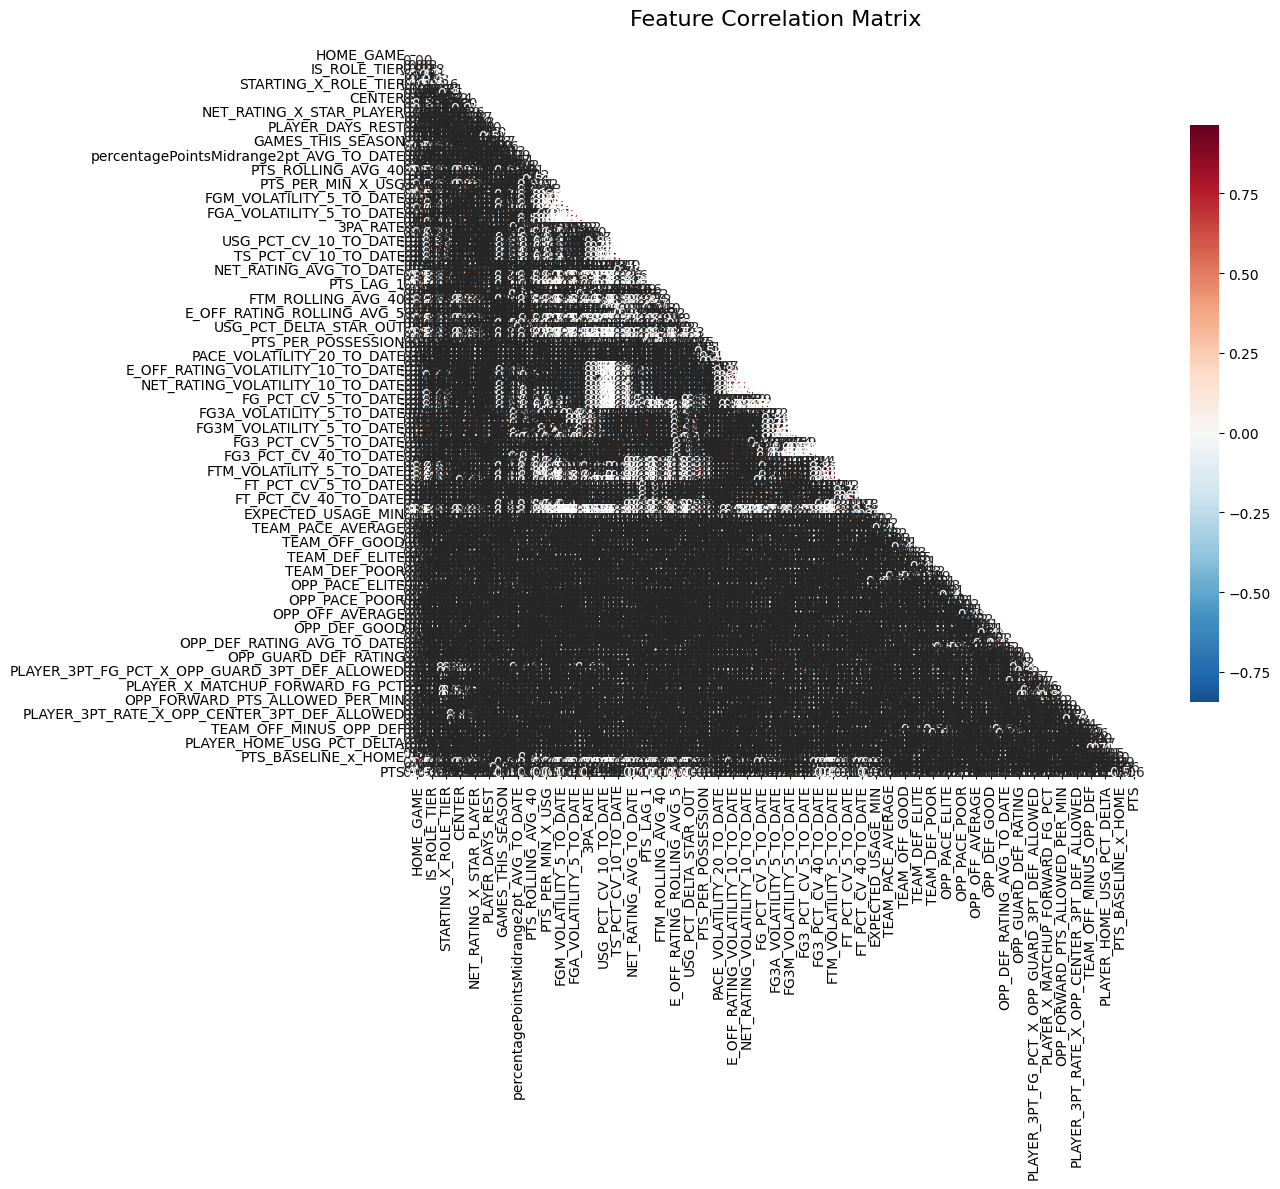

TOP 10 FEATURES MOST CORRELATED WITH TARGET:
 1. PTS_ROLLING_AVG_40             0.681
 2. EXPECTED_USAGE_MIN             0.676
 3. FGA_ROLLING_AVG_10             0.673
 4. PTS_PER_MIN_X_MIN_LAG          0.658
 5. PTS_PER_MIN_X_USG              0.623
 6. FTM_ROLLING_AVG_40             0.605
 7. USAGE_X_EFFICIENCY             0.603
 8. USG_PCT_AVG_TO_DATE            0.600
 9. MATCHUP_AVG_PTS_TO_DATE        0.590
10. FGA_LAG_1                      0.589
REMOVED: PLAYER_IS_TEAM_STAR            (corr with PTS_X_STAR_PLAYER: 0.964)
REMOVED: FGA_ROLLING_AVG_10             (corr with EXPECTED_USAGE_MIN: 0.963)

SUMMARY:
Original features: 150
Removed features: 2
Final features: 148


In [10]:
corr_matrix, top_10_features = correlation_analysis(train_df, top_features)

final_features = remove_highly_correlated_features(train_df, top_features, threshold=0.95)

### NGBOOST MODEL

In [11]:
pts_mean, pts_var, calibration_factor = fit_ngboost_split(train_df,
                     None,
                     top_features,
                     target_col='PTS',
                     distribution=Normal,
                     player_col='PLAYER_ID',
                     recent_n=60,
                     recent_weight=2.0,
                     variance_recent_weight=1.0,
                     variance_lr=0.08,  # Higher learning rate for variance
                     variance_max_depth=6,  # Deeper trees for variance
                     variance_n_estimators=300,
                     variance_calibration_factor=1.25)  # Calibration to inflate variance


In [5]:
validate_production_model(pts_mean, pts_var, val_df, top_features, 'PTS', calibration_factor)

=== CALIBRATION CHECK ===
Standardized residuals mean: 0.012 (should be ~0)
Standardized residuals std: 1.027 (should be ~1)
Q10: Predicted=5.0, Actual=3.0
Q25: Predicted=8.4, Actual=6.0
Q50: Predicted=12.3, Actual=11.0
Q75: Predicted=16.1, Actual=17.0
Q90: Predicted=19.6, Actual=24.0

MAE: 4.67
90% CI: Coverage=90.45%, Expected=90.00%
95% CI: Coverage=95.03%, Expected=95.00%
99% CI: Coverage=98.53%, Expected=99.00%


array([ 1.03859771,  0.52835125,  1.63845235, ..., -0.59086014,
        0.82016537,  0.93266908], shape=(22104,))

In [6]:
# Calibration is now built into fit_ngboost_split and predict_mean_variance_split
# Test predictions with calibrated variance
from MODELS.ngboostModel import predict_mean_variance_split
mu, var = predict_mean_variance_split(pts_mean, pts_var, val_df, top_features, calibration_factor)
print(f"Mean predictions: {mu[:5]}")
print(f"Variance predictions: {var[:5]}")

Mean predictions: [ 9.76666568 17.59958565 19.91048432 19.57617384 20.43250879]
Variance predictions: [36.02019968 41.42077387 54.44401879 70.0954484  45.25699405]


### Plot SHAP values per position to verify the model leans on the right drivers

In [ ]:
# analyze_shap(model, val_df, top_features, 'PTS')
# Note: SHAP requires a single model. Use split models with predict_mean_variance_split() instead

In [13]:
# Save NGBoost split models (mean, variance, and calibration factor)
joblib.dump(pts_mean, 'SAVED_MODELS/NGBOOST_PTS_MEAN_MODEL.pkl')
joblib.dump(pts_var, 'SAVED_MODELS/NGBOOST_PTS_VAR_MODEL.pkl')
joblib.dump(calibration_factor, 'SAVED_MODELS/NGBOOST_PTS_CALIBRATION_FACTOR.pkl')

joblib.dump(top_features, 'SAVED_MODELS/feature_list.pkl')

print(f"Saved models with calibration factor: {calibration_factor}")

Saved models with calibration factor: 1.25
